# E2-b：轨迹内动态噪声在线自适应（仅 beta）

本 notebook 在单一离线模型（`train qc=0.05`）上验证在线自适应，重点考察对**轨迹内动态噪声（varyQ）**的适应能力。

全程对比方法：
- `EKF baseline`
- `Joint (no-adapt)`
- `Joint + online beta-adapt`


## 1）环境准备

导入依赖，定位项目根目录（`src/`），选择设备并设置随机种子。


In [68]:
from __future__ import annotations

from pathlib import Path
import copy
import subprocess
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

try:
    import pandas as pd  # type: ignore
except Exception:
    pd = None  # type: ignore

from src.data.components import MeasurementDataset
from src.data.components.splits import (
    create_splits_file_name,
    load_splits_file,
    obtain_tr_val_test_warm_idx,
    save_splits_file,
)
from src.models.lit_module import GruAugmentedEkfLitModule


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT  :", ROOT)
print("device:", device)

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

plt.rcParams["figure.dpi"] = 140


ROOT  : d:\LiLei\Python_projects\GRU_augmented_EKF
device: cuda


## 2）Checkpoint 与数据集

- 离线 checkpoint：固定 `train qc=0.05` 的 joint 模型（来自 E1）
- `varyQ` 数据集：轨迹内 qc 随时间变化的测试集（缺失时自动生成）


In [ ]:
CKPT_JOINT = (
    ROOT
    / Path(
        r"outputs/2026-02-05/22-45-29_E1/outputs/2026-02-05/22-45-29/checkpoints/E1.ckpt"
    )
).resolve()
assert CKPT_JOINT.exists(), f"Checkpoint not found: {CKPT_JOINT}"

DATA_VARYQ = (
    ROOT
    / Path(
        r"data/raw/trajectory_varyQ_qc005_05_5/trajectory_wpi/trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K6_randWin_randDir_varyQ.npz"
    )
).resolve()

if not DATA_VARYQ.exists():
    print("varyQ dataset not found. Generating:", DATA_VARYQ)
    out_root = (ROOT / "data/raw/trajectory_varyQ_qc005_05_5").resolve()
    out_root.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        str(ROOT / "src/data/components/data_generator_varyQ.py"),
        "--case",
        "mismatch",
        "--trajectories",
        "300",
        "--steps",
        "500",
        "--dt",
        "0.01",
        "--qc",
        "0.05",
        "--sigma-r",
        "0.05",
        "--seed",
        "0",
        "--turn-length",
        "25",
        "--turn-count",
        "6",
        "--random-turn-windows",
        "--random-turn-directions",
        "--qc-multipliers",
        "0.1",
        "1",
        "10",
        "--out-root",
        str(out_root),
    ]
    print("Running command:")
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)

assert DATA_VARYQ.exists(), f"varyQ dataset not found: {DATA_VARYQ}"

print("CKPT_JOINT:", CKPT_JOINT)
print()
print("varyQ dataset:")
print("  -", DATA_VARYQ.name)


CKPT_JOINT: D:\LiLei\Python_projects\GRU_augmented_EKF\outputs\2026-02-05\22-45-29_E1\outputs\2026-02-05\22-45-29\checkpoints\E1.ckpt

varyQ dataset:
  - trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K6_randWin_randDir_varyQ.npz


## 3）数据加载与划分

加载 `X/Y` 和元数据，读取已有 split 文件（不存在则自动创建）。


In [70]:
def ensure_splits(
    dataset_path: Path,
    *,
    seed: int = 0,
    tr_to_test_split: float = 0.9,
    tr_to_val_split: float = 0.8333,
    warm_fraction: float = 0.1,
) -> dict:
    splits_path = create_splits_file_name(dataset_path, splits_name="")
    if splits_path.exists():
        return load_splits_file(splits_path)

    ds = MeasurementDataset(dataset_path)
    train_idx, val_idx, test_idx, warm_idx = obtain_tr_val_test_warm_idx(
        ds,
        tr_to_test_split,
        tr_to_val_split,
        warm_fraction,
        seed=seed,
    )
    splits = {"train": train_idx, "val": val_idx, "test": test_idx, "warm": warm_idx}
    save_splits_file(splits_path, splits)
    return splits


def load_test_split(dataset_path: Path, *, seed: int = 0) -> tuple[np.ndarray, np.ndarray, dict]:
    with np.load(dataset_path, allow_pickle=True) as data:
        X_all = np.asarray(data["X"], dtype=float)
        Y_all = np.asarray(data["Y"], dtype=float)

        meta: dict[str, object] = {
            "qc": float(np.asarray(data.get("qc", np.nan))),
            "sigma_r": float(np.asarray(data.get("sigma_r", np.nan))),
            "dt": float(np.asarray(data.get("dt", np.nan))),
            "steps": int(np.asarray(data.get("steps", Y_all.shape[1]))),
            "trajectories": int(np.asarray(data.get("trajectories", Y_all.shape[0]))),
            "turn_length": int(np.asarray(data.get("turn_length", 50))),
            "turn_count": int(np.asarray(data.get("turn_count", 3))),
            "random_turn_windows": bool(np.asarray(data.get("random_turn_windows", False))),
            "random_turn_directions": bool(np.asarray(data.get("random_turn_directions", False))),
        }
        if "qc_schedule" in data.files:
            meta["qc_schedule"] = np.asarray(data["qc_schedule"], dtype=float)
        if "qc_multipliers" in data.files:
            meta["qc_multipliers"] = np.asarray(data["qc_multipliers"], dtype=float)

    splits = ensure_splits(dataset_path, seed=seed)
    test_idx = np.asarray(splits["test"], dtype=int)
    return X_all[test_idx], Y_all[test_idx], meta


## 4）模型与评估工具

定义：
- 模型加载器（`EKF baseline`、`joint`）
- no-adapt 推理
- 汇总指标（`pos_RMSE`、`mean_NLL`、`mean_NIS/m` 等）
- varyQ 分段 beta 统计


In [71]:
def load_hparams(ckpt_path: Path) -> dict:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    return ckpt.get("hyper_parameters", {})


HP_REF = load_hparams(CKPT_JOINT)
print("HP_REF keys:", len(HP_REF))


def build_ekf_baseline(dataset_path: Path) -> GruAugmentedEkfLitModule:
    hp = dict(HP_REF)
    hp["dataset_path"] = str(dataset_path)
    hp["max_delta"] = 0.0
    hp["dynamics_use_beta_head"] = False
    hp["train_stage"] = "joint"
    hp["dynamics_feature_mode"] = "basic"
    return GruAugmentedEkfLitModule(**hp)


def load_joint_model(dataset_path: Path) -> GruAugmentedEkfLitModule:
    model = GruAugmentedEkfLitModule.load_from_checkpoint(
        str(CKPT_JOINT),
        map_location="cpu",
        dataset_path=str(dataset_path),
    )
    model.dynamics.use_beta_head = True
    return model


def run_filter_no_adapt(model: GruAugmentedEkfLitModule, Y_np: np.ndarray) -> dict[str, np.ndarray]:
    model = model.to(device)
    model.eval()

    obs = torch.as_tensor(Y_np, dtype=torch.float32, device=device)
    B, _, _ = obs.shape
    x0 = torch.zeros(B, model.state_dim, device=device)
    Sigma0 = (
        torch.eye(model.state_dim, device=device)
        .unsqueeze(0)
        .expand(B, -1, -1)
        * float(model.sigma0_scale)
    )
    hidden = (
        model.dynamics.reset_hidden(B, device=device, dtype=obs.dtype)
        if getattr(model.dynamics, "use_gru", False)
        else None
    )
    with torch.no_grad():
        outputs = model.ekf(obs, x0, Sigma0, mask=None, hidden=hidden)
    return {k: v.detach().cpu().numpy() for k, v in outputs.items() if isinstance(v, torch.Tensor)}


def summarize(truth_X: np.ndarray, out: dict[str, np.ndarray]) -> dict[str, float]:
    x_filt = out["x_filt"]
    whitened = out["whitened"]
    logdet = out["logdet_S"]

    nis = np.sum(whitened**2, axis=-1)
    nll = nis + logdet
    m = int(whitened.shape[-1])

    err = truth_X - x_filt
    pos_err = np.linalg.norm(err[..., :2], axis=-1)

    mse_pos = float(np.mean(np.sum(err[..., :2] * err[..., :2], axis=-1)))
    mse_vel = float(np.mean(np.sum(err[..., 2:4] * err[..., 2:4], axis=-1))) if err.shape[-1] >= 4 else float("nan")

    stats: dict[str, float] = {
        "pos_RMSE": float(np.sqrt(mse_pos)),
        "vel_RMSE": float(np.sqrt(mse_vel)) if np.isfinite(mse_vel) else float("nan"),
        "pos_err_p95": float(np.quantile(pos_err, 0.95)),
        "mean_NLL": float(np.mean(nll)),
        "mean_NIS/m": float(np.mean(nis) / float(m)),
    }
    if "beta" in out:
        beta = out["beta"][..., 0]
        stats["beta_mean"] = float(np.mean(beta))
        stats["beta_std"] = float(np.std(beta))
    if "delta" in out:
        delta = out["delta"]
        stats["delta_rms"] = float(np.sqrt(np.mean(np.sum(delta * delta, axis=-1))))
    return stats


def summarize_varyq(
    truth_X: np.ndarray,
    out: dict[str, np.ndarray],
    *,
    qc_schedule: np.ndarray,
    qc_base: float,
) -> dict[str, float]:
    stats = summarize(truth_X, out)
    if "beta" in out and np.isfinite(qc_base) and qc_schedule.ndim == 1 and qc_schedule.size == out["beta"].shape[1]:
        expected_beta = qc_schedule / float(qc_base)
        beta = out["beta"][..., 0]
        stats["beta_MAE_to_expected"] = float(np.mean(np.abs(beta - expected_beta[None, :])))
    else:
        stats["beta_MAE_to_expected"] = float("nan")
    return stats


def detect_segments_from_schedule(qc_schedule: np.ndarray) -> list[dict[str, float | int]]:
    q = np.asarray(qc_schedule, dtype=float).reshape(-1)
    if q.size == 0:
        return []

    change_idx = np.where(np.abs(np.diff(q)) > 1e-12)[0] + 1
    bounds = [0, *change_idx.tolist(), q.size]

    finite_vals = q[np.isfinite(q)]
    base_qc = float(np.median(finite_vals)) if finite_vals.size > 0 else float("nan")

    segs: list[dict[str, float | int]] = []
    for i, (s, e) in enumerate(zip(bounds[:-1], bounds[1:]), start=1):
        q_seg = float(np.mean(q[s:e]))
        expected_beta = q_seg / base_qc if np.isfinite(base_qc) and base_qc != 0 else float("nan")
        segs.append(
            {
                "segment": i,
                "start": int(s),
                "end": int(e),
                "qc_segment": q_seg,
                "qc_base": base_qc,
                "expected_beta": float(expected_beta),
            }
        )
    return segs


def segment_beta_stats(beta_bt: np.ndarray, segs: list[dict[str, float | int]]) -> list[dict[str, float | int]]:
    rows: list[dict[str, float | int]] = []
    for seg in segs:
        s = int(seg["start"])
        e = int(seg["end"])
        chunk = beta_bt[:, s:e]
        if chunk.size == 0:
            continue

        beta_mean = float(np.mean(chunk))
        beta_std = float(np.std(chunk))
        expected_beta = float(seg["expected_beta"])

        rows.append(
            {
                "segment": int(seg["segment"]),
                "start": s,
                "end": e,
                "qc_segment": float(seg["qc_segment"]),
                "expected_beta": expected_beta,
                "beta_mean": beta_mean,
                "beta_std": beta_std,
                "beta_abs_err": float(abs(beta_mean - expected_beta)) if np.isfinite(expected_beta) else float("nan"),
            }
        )
    return rows


HP_REF keys: 35


## 5）在线自适应（仅更新 `fc_beta`）

在线自适应策略：
- 冻结除 `fc_beta` 外的所有参数
- 按 chunk 因果顺序更新
- 默认损失为 NIS 校准（`mean_NIS/m -> 1`）


In [72]:
def prepare_beta_only(
    model: GruAugmentedEkfLitModule,
    *,
    beta_min: float | None = None,
    beta_max: float | None = None,
) -> None:
    model.train_stage = "beta"
    model._apply_train_stage()  # noqa: SLF001
    model.dynamics.use_beta_head = True
    if beta_min is not None:
        model.dynamics.beta_min = float(beta_min)
    if beta_max is not None:
        model.dynamics.beta_max = float(beta_max)
    if float(model.dynamics.beta_max) <= float(model.dynamics.beta_min):
        raise ValueError("Require adapt beta_max > beta_min.")
    # Keep train() enabled so beta-head parameters can receive gradients.
    model.train()

In [73]:
def online_adapt_beta_one_traj(
    model: GruAugmentedEkfLitModule,
    y_traj: np.ndarray,
    *,
    chunk_len: int = 50,
    lr: float = 1e-3,
    steps_per_chunk: int = 1,
    loss_mode: str = "nis",
    target_nis_m: float = 1.0,
    lambda_beta: float = 0.01,    # 新增：λ_β (正则化系数)
    lambda_d_beta: float = 1.0,   # 新增：λ_Δβ (平滑项系数)
) -> dict[str, np.ndarray]:
    obs = torch.as_tensor(y_traj, dtype=torch.float32, device=device).unsqueeze(0)
    _, T, m = obs.shape

    # --- 初始化状态 ---
    x0 = torch.zeros(1, model.state_dim, device=device)
    Sigma0 = torch.eye(model.state_dim, device=device).unsqueeze(0).expand(1, -1, -1) * float(model.sigma0_scale)
    hidden = model.dynamics.reset_hidden(1, device=device, dtype=obs.dtype) if getattr(model.dynamics, "use_gru", False) else None

    # --- 优化器：仅更新噪声头参数 ---
    params = list(model.dynamics.fc_beta.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    keep_keys = ["x_filt", "whitened", "logdet_S", "beta", "delta"]
    collected: dict[str, list[torch.Tensor]] = {k: [] for k in keep_keys}

    for start in range(0, T, chunk_len):
        end = min(start + chunk_len, T)
        obs_chunk = obs[:, start:end, :]

        # 记录 chunk 开始时的因果状态
        x0_start, Sigma0_start = x0.detach(), Sigma0.detach()
        hidden_start = hidden.detach() if hidden is not None else None

        # --- 在线优化 (θ_β 步进) ---
        for _ in range(max(int(steps_per_chunk), 1)):
            opt.zero_grad(set_to_none=True)
            out_adapt = model.ekf(obs_chunk, x0_start, Sigma0_start, mask=None, hidden=hidden_start)
            
            # 1. 似然项 (Likelihood Term / NIS)
            nis = out_adapt["whitened"].pow(2).sum(dim=-1)
            if loss_mode == "nis":
                loss_main = ((nis.mean() / float(m)) - float(target_nis_m)) ** 2
            elif loss_mode == "nll":
                loss_main = (nis + out_adapt["logdet_S"]).mean() # 对应公式第一部分
            else:
                raise ValueError(f"Unknown loss_mode: {loss_mode}")

            # 2. 绝对正则项 (Beta Regularization)
            log_beta = torch.log(out_adapt["beta"] + 1e-9)
            loss_reg = lambda_beta * log_beta.pow(2).mean() # 对应公式第二部分 (λ_β)

            # 3. 时间平滑项 (Temporal Smoothness)
            if log_beta.shape[1] > 1:
                # 对应公式第三部分 (λ_Δβ)
                loss_smooth = lambda_d_beta * (log_beta[:, 1:] - log_beta[:, :-1]).pow(2).mean()
            else:
                loss_smooth = 0.0

            total_loss = loss_main + loss_reg + loss_smooth
            total_loss.backward()
            
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            opt.step()

        # --- 执行最终滤波并推进状态 ---
        with torch.no_grad():
            outputs = model.ekf(obs_chunk, x0, Sigma0, mask=None, hidden=hidden)
            for k in keep_keys:
                if k in outputs:
                    collected[k].append(outputs[k].detach().cpu())

            x0 = outputs["x_filt"][:, -1].detach()
            Sigma0 = outputs["Sigma_filt"][:, -1].detach()
            hidden = outputs.get("hidden_last")
            if hidden is not None:
                hidden = hidden.detach()

    return {k: torch.cat(v, dim=1).numpy() for k, v in collected.items() if len(v) > 0}

In [74]:
def run_filter_online_beta_adapt(
    base_model: GruAugmentedEkfLitModule,
    Y_np: np.ndarray,
    *,
    chunk_len: int = 50,
    lr: float = 1e-3,
    steps_per_chunk: int = 1,
    loss_mode: str = "nis",
    target_nis_m: float = 1.0,
    adapt_beta_min: float | None = None,
    adapt_beta_max: float | None = None,
    lambda_beta: float = 0.0,
    lambda_d_beta: float = 0.0,
) -> dict[str, np.ndarray]:
    base_model = base_model.to(device)
    base_model.eval()
    base_state = copy.deepcopy({k: v.detach().cpu() for k, v in base_model.state_dict().items()})

    outs = []
    B = int(Y_np.shape[0])
    for b in range(B):
        base_model.load_state_dict(base_state, strict=True)
        prepare_beta_only(base_model, beta_min=adapt_beta_min, beta_max=adapt_beta_max)

        out_b = online_adapt_beta_one_traj(
            base_model,
            Y_np[b],
            chunk_len=chunk_len,
            lr=lr,
            steps_per_chunk=steps_per_chunk,
            loss_mode=loss_mode,
            target_nis_m=target_nis_m,
            lambda_beta=lambda_beta,
            lambda_d_beta=lambda_d_beta,
        )
        outs.append(out_b)

    keys = outs[0].keys()
    stacked = {k: np.concatenate([o[k] for o in outs], axis=0) for k in keys}

    # Restore offline weights after trajectory loop to avoid cross-trajectory contamination.
    base_model.load_state_dict(base_state, strict=True)
    base_model.eval()
    return stacked


## 6）运行 E3-b：varyQ（`qc(t)` 随时间变化）

在 varyQ 上运行同样三种方法，并报告：
- 全局指标
- beta 与期望值误差
- 分段 beta 统计


In [89]:
MAX_TEST_TRAJ = 10  # Set to 10 for quick debug runs.
ADAPT_CHUNK = 5
LAMBDA_BETA = 0.0001  # Penalty on log-beta magnitude (from Grid Search)
LAMBDA_D_BETA = 0.1   # Penalty on log-beta temporal change (from Grid Search)
ADAPT_LR = 3e-3
ADAPT_STEPS = 2
LOSS_MODE = "nis"  # Options: "nis" or "nll"
ADAPT_BETA_MIN = 0.05
ADAPT_BETA_MAX = 200.0  # enlarged beta upper bound for heavy qc shift

X_vq, Y_vq, meta_vq = load_test_split(DATA_VARYQ, seed=seed)

if MAX_TEST_TRAJ is not None:
    X_vq_eval = X_vq[:MAX_TEST_TRAJ]
    Y_vq_eval = Y_vq[:MAX_TEST_TRAJ]
else:
    X_vq_eval = X_vq
    Y_vq_eval = Y_vq

qc_base = float(meta_vq.get("qc", np.nan))
qc_schedule = np.asarray(meta_vq.get("qc_schedule", np.full(Y_vq_eval.shape[1], np.nan)), dtype=float)

if qc_schedule.ndim == 1 and np.all(np.isfinite(qc_schedule)) and qc_schedule.size == Y_vq_eval.shape[1]:
    segs_vq = detect_segments_from_schedule(qc_schedule)
else:
    T = Y_vq_eval.shape[1]
    cuts = [0, T // 3, 2 * T // 3, T]
    q_vals = [qc_base * 0.1, qc_base, qc_base * 10.0]
    segs_vq = []
    for i, (s, e) in enumerate(zip(cuts[:-1], cuts[1:]), start=1):
        q_seg = float(q_vals[i - 1])
        segs_vq.append(
            {
                "segment": i,
                "start": s,
                "end": e,
                "qc_segment": q_seg,
                "qc_base": qc_base,
                "expected_beta": q_seg / qc_base if np.isfinite(qc_base) and qc_base != 0 else float("nan"),
            }
        )

expected_beta_t = np.full(Y_vq_eval.shape[1], np.nan, dtype=float)
for seg in segs_vq:
    expected_beta_t[int(seg["start"]): int(seg["end"])] = float(seg["expected_beta"])

model_ekf_vq = build_ekf_baseline(DATA_VARYQ)
model_joint_vq = load_joint_model(DATA_VARYQ)

out_vq_ekf = run_filter_no_adapt(model_ekf_vq, Y_vq_eval)
out_vq_no = run_filter_no_adapt(model_joint_vq, Y_vq_eval)
out_vq_adapt = run_filter_online_beta_adapt(
    model_joint_vq,
    Y_vq_eval,
    chunk_len=ADAPT_CHUNK,
    lr=ADAPT_LR,
    steps_per_chunk=ADAPT_STEPS,
    loss_mode=LOSS_MODE,
    target_nis_m=1.0,
    adapt_beta_min=ADAPT_BETA_MIN,
    adapt_beta_max=ADAPT_BETA_MAX,
    lambda_beta=LAMBDA_BETA,
    lambda_d_beta=LAMBDA_D_BETA,
)

rows_e3b = []
for method, out in [
    ("EKF baseline", out_vq_ekf),
    ("Joint (no-adapt)", out_vq_no),
    ("Joint + online beta-adapt", out_vq_adapt),
]:
    rows_e3b.append(
        {
            "method": method,
            **summarize_varyq(X_vq_eval, out, qc_schedule=qc_schedule, qc_base=qc_base),
        }
    )

rows_e3b_seg = []
for method, out in [
    ("Joint (no-adapt)", out_vq_no),
    ("Joint + online beta-adapt", out_vq_adapt),
]:
    if "beta" in out:
        beta_bt = np.asarray(out["beta"][..., 0], dtype=float)
        for seg_row in segment_beta_stats(beta_bt, segs_vq):
            seg_row["method"] = method
            rows_e3b_seg.append(seg_row)

if pd is None:
    print("rows_e3b:")
    for r in rows_e3b:
        print(r)
    print("rows_e3b_seg:")
    for r in rows_e3b_seg:
        print(r)
else:
    df_e3b = pd.DataFrame(rows_e3b)
    method_order = ["EKF baseline", "Joint (no-adapt)", "Joint + online beta-adapt"]
    df_e3b["method"] = pd.Categorical(df_e3b["method"], categories=method_order, ordered=True)
    df_e3b = df_e3b.sort_values(["method"]).reset_index(drop=True)

    df_e3b_seg = pd.DataFrame(rows_e3b_seg) if rows_e3b_seg else pd.DataFrame()
    if not df_e3b_seg.empty:
        df_e3b_seg["method"] = pd.Categorical(df_e3b_seg["method"], categories=method_order, ordered=True)
        df_e3b_seg = df_e3b_seg.sort_values(["segment", "method"]).reset_index(drop=True)

    df_e3b


## 7）E3-b 表格与后半段（Post-Adapt）指标

本节展示：
- E3-b 全时域指标
- 分段 beta 统计
- E3-b 后半段（second-half）指标表


In [90]:
if pd is None:
    print("pandas is not installed; skip formatted table display.")
else:
    try:
        from IPython.display import display as _display
    except Exception:
        _display = None

    def _show(df):
        if _display is not None:
            _display(df)
        else:
            print(df.to_string(index=False))

    cols_main = [
        "method",
        "pos_RMSE",
        "vel_RMSE",
        "mean_NLL",
        "mean_NIS/m",
        "beta_mean",
        "beta_std",
        "beta_MAE_to_expected",
    ]
    print("E3-b full-horizon metrics:")
    _show(df_e3b.reindex(columns=cols_main))

    if "df_e3b_seg" in globals() and not df_e3b_seg.empty:
        print("E3-b segment-wise beta statistics:")
        _show(df_e3b_seg)

    def _slice_time_out(out: dict[str, np.ndarray], t_start: int) -> dict[str, np.ndarray]:
        out_sliced: dict[str, np.ndarray] = {}
        for k, v in out.items():
            if isinstance(v, np.ndarray) and v.ndim >= 2 and v.shape[1] >= t_start:
                out_sliced[k] = v[:, t_start:, ...]
            else:
                out_sliced[k] = v
        return out_sliced

    # --- E3-b post-adapt metrics (second half) ---
    t0_vq = int(X_vq_eval.shape[1] // 2)
    X_vq_post = X_vq_eval[:, t0_vq:, :]
    qc_schedule_post = qc_schedule[t0_vq:]

    rows_post_e3b = []
    for method, out in [
        ("EKF baseline", out_vq_ekf),
        ("Joint (no-adapt)", out_vq_no),
        ("Joint + online beta-adapt", out_vq_adapt),
    ]:
        s_post = summarize_varyq(
            X_vq_post,
            _slice_time_out(out, t0_vq),
            qc_schedule=qc_schedule_post,
            qc_base=qc_base,
        )
        rows_post_e3b.append({"method": method, **s_post})

    df_post_e3b = pd.DataFrame(rows_post_e3b)
    method_order = ["EKF baseline", "Joint (no-adapt)", "Joint + online beta-adapt"]
    df_post_e3b["method"] = pd.Categorical(df_post_e3b["method"], categories=method_order, ordered=True)
    df_post_e3b = df_post_e3b.sort_values(["method"]).reset_index(drop=True)

    print(f"E3-b post-adapt metrics (t >= {t0_vq}):")
    _show(df_post_e3b.reindex(columns=cols_main))



E3-b full-horizon metrics:


,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,EKF baseline,0.122000,1.209738,-14.696723,2.244836,1.000000,0.000000,36.252000
1,Joint (no-adapt),0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
2,Joint + online beta-adapt,0.037549,1.764694,-19.095261,1.123350,6.394847,17.442108,32.447753


E3-b segment-wise beta statistics:


,segment,start,end,qc_segment,expected_beta,beta_mean,beta_std,beta_abs_err,method
0,1,0,166,0.05,0.1,1.352041,0.040687,1.252041,Joint (no-adapt)
1,1,0,166,0.05,0.1,1.503779,0.558480,1.403779,Joint + online beta-adapt
2,2,166,332,0.50,1.0,1.318167,0.055535,0.318167,Joint (no-adapt)
3,2,166,332,0.50,1.0,3.113962,1.712334,2.113962,Joint + online beta-adapt
4,3,332,500,5.00,10.0,1.268754,0.091539,8.731246,Joint (no-adapt)
5,3,332,500,5.00,10.0,14.469517,28.332993,4.469517,Joint + online beta-adapt


E3-b post-adapt metrics (t >= 250):


,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,EKF baseline,0.163639,1.572989,-11.812075,2.979484,1.000000,0.000000,69.480000
1,Joint (no-adapt),0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
2,Joint + online beta-adapt,0.045464,2.145202,-18.987885,1.149590,10.938609,23.794455,62.043866


## 8）E3-b 可视化

可视化：
- `beta(t)` 与期望 beta 对比
- `NIS/m` 随时间变化
- 平均位置误差随时间变化


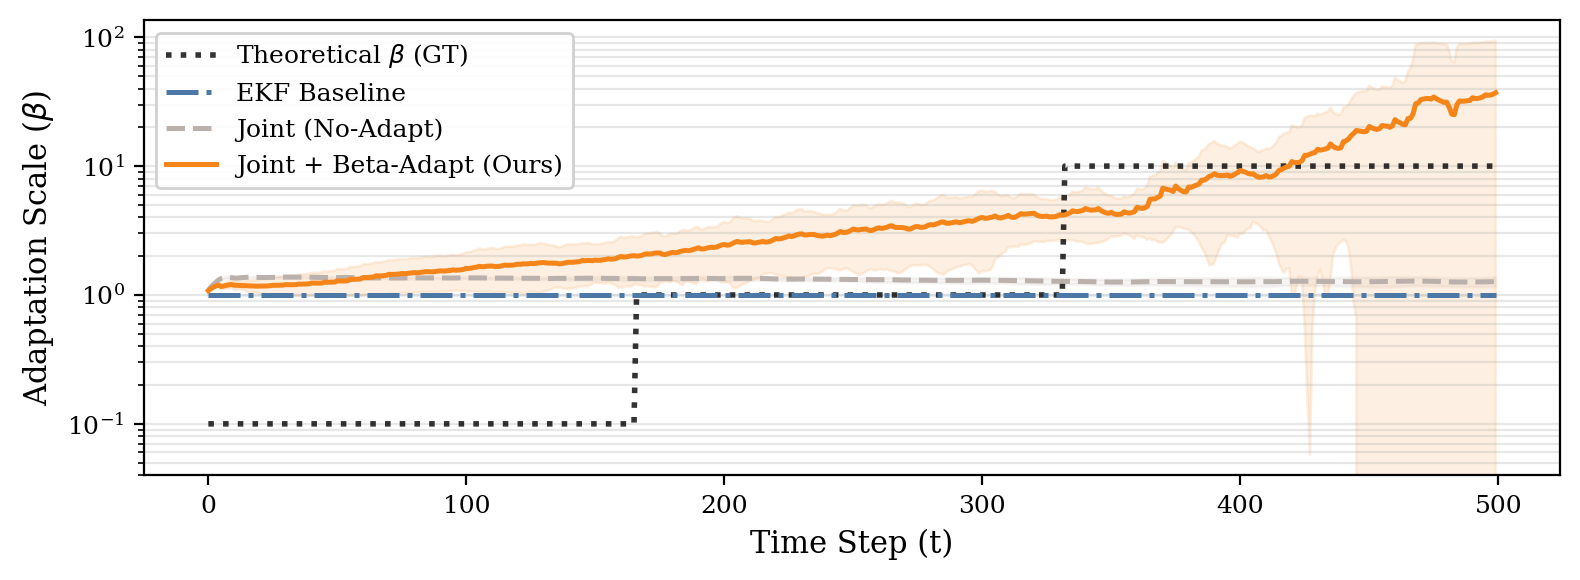

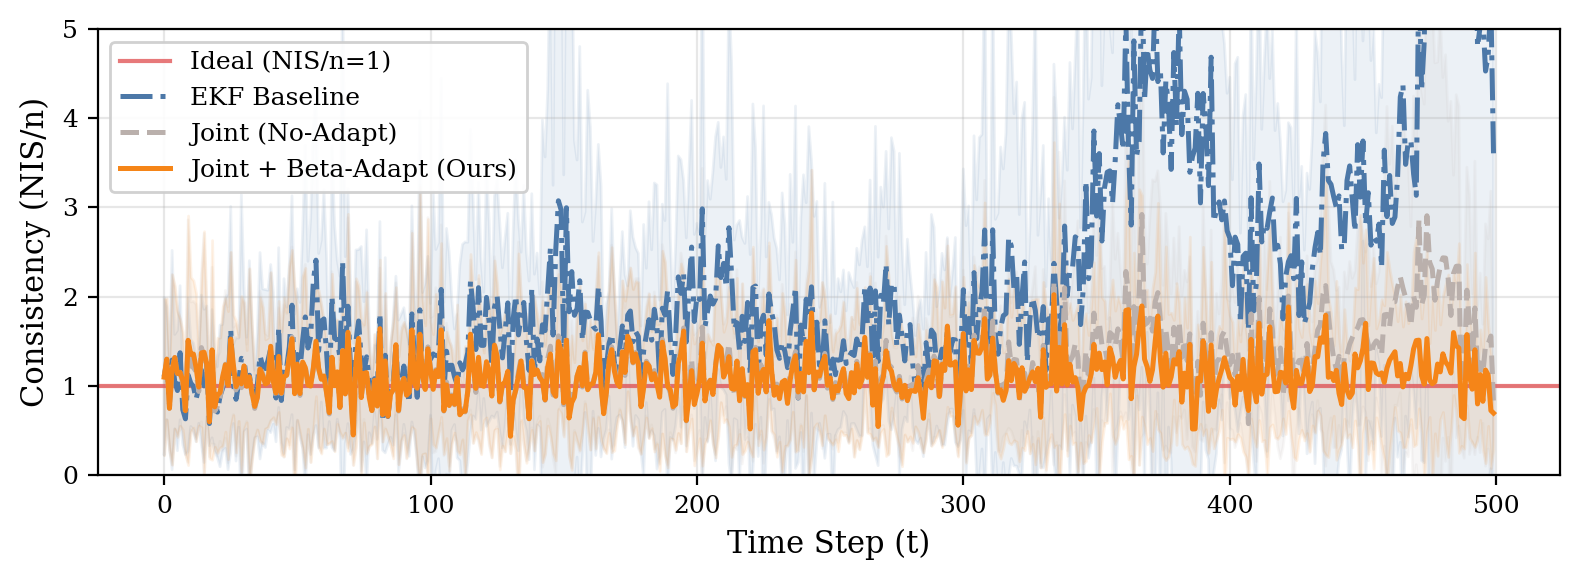

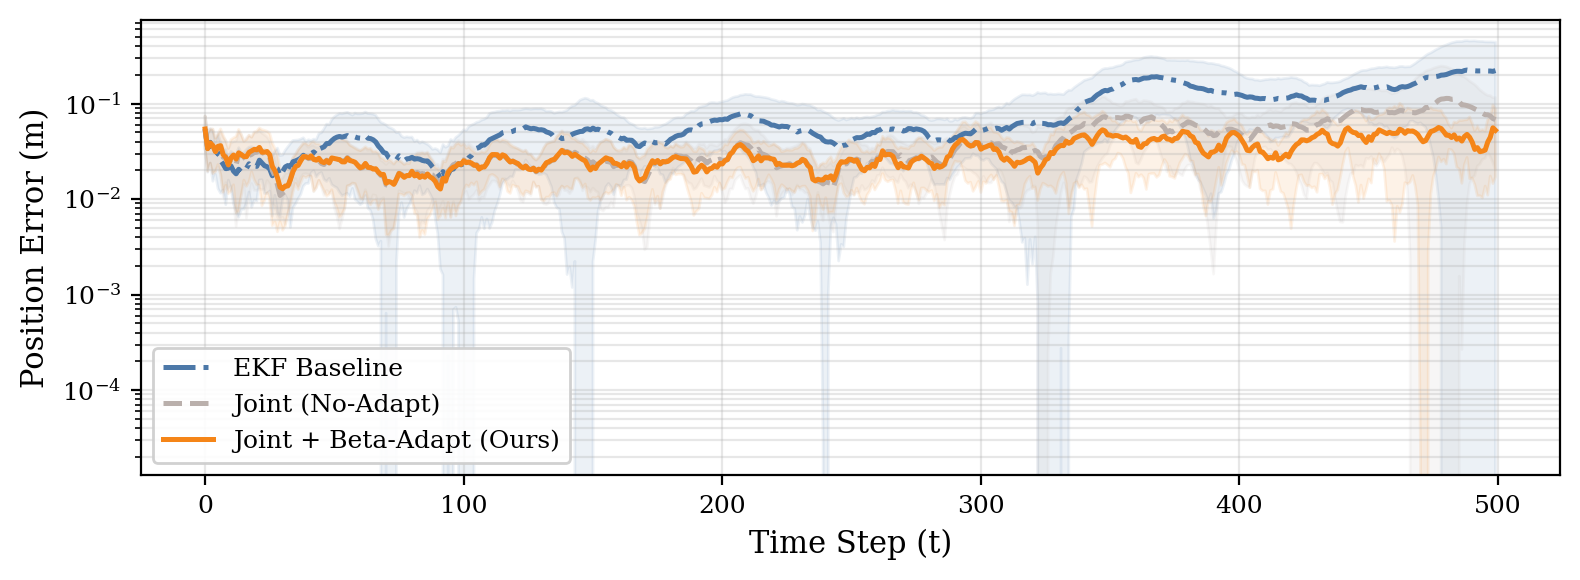

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# --- 设置对齐后的学术绘图风格 ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.8,
    "grid.alpha": 0.3,
    "figure.dpi": 200
})

def get_stats(arr):
    return np.mean(arr, axis=0), np.std(arr, axis=0)

# --- 核心配色对齐 ---
methods_to_plot = [
    ("EKF Baseline", out_vq_ekf, "#4C78A8", "-."),
    ("Joint (No-Adapt)", out_vq_no, "#BAB0AC", "--"),
    ("Joint + Beta-Adapt (Ours)", out_vq_adapt, "#F58518", "-")
]

T = X_vq_eval.shape[1]
time = np.arange(T)

# ===================== Figure 1: Beta Tracking =====================
fig1, ax_beta = plt.subplots(figsize=(8, 3))
ax_beta.plot(time, expected_beta_t, color='black', linestyle=':', label='Theoretical $\\beta$ (GT)', alpha=0.8, linewidth=2)

for name, out, color, ls in methods_to_plot:
    if "beta" in out:
        beta_vals = out["beta"][..., 0] 
        mu, sigma = get_stats(beta_vals)
        ax_beta.plot(time, mu, label=name, color=color, linestyle=ls)
        ax_beta.fill_between(time, mu - sigma, mu + sigma, color=color, alpha=0.12)

ax_beta.set_ylabel("Adaptation Scale ($\\beta$)")
ax_beta.set_xlabel("Time Step (t)")
ax_beta.set_yscale('log')
ax_beta.grid(True, which='both', axis='y')
ax_beta.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# ===================== Figure 2: NIS Consistency =====================
fig2, ax_nis = plt.subplots(figsize=(8, 3))
ax_nis.axhline(y=1.0, color='#E15759', linestyle='-', linewidth=1.5, label='Ideal (NIS/n=1)', alpha=0.8)

for name, out, color, ls in methods_to_plot:
    whitened = out["whitened"]
    m = whitened.shape[-1]
    nis = np.sum(whitened**2, axis=-1) / m
    mu, sigma = get_stats(nis)
    ax_nis.plot(time, mu, label=name, color=color, linestyle=ls)
    ax_nis.fill_between(time, mu - sigma, mu + sigma, color=color, alpha=0.1)

ax_nis.set_ylabel("Consistency (NIS/n)")
ax_nis.set_xlabel("Time Step (t)")
ax_nis.set_ylim(0, 5) 
ax_nis.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)  # 改为左边
ax_nis.grid(True)
plt.tight_layout()
plt.show()

# ===================== Figure 3: Position Error =====================
fig3, ax_err = plt.subplots(figsize=(8, 3))

for name, out, color, ls in methods_to_plot:
    err = X_vq_eval - out["x_filt"]
    pos_err = np.linalg.norm(err[..., :2], axis=-1) 
    mu, sigma = get_stats(pos_err)
    ax_err.plot(time, mu, label=name, color=color, linestyle=ls)
    ax_err.fill_between(time, mu - sigma, mu + sigma, color=color, alpha=0.1)

ax_err.set_ylabel("Position Error (m)")
ax_err.set_xlabel("Time Step (t)")
ax_err.set_yscale('log')
ax_err.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)  # 改为左下
ax_err.grid(True, which='both')
plt.tight_layout()
plt.show()

## 9a）Grid_Search_for_Loss

In [78]:
# --- E3-b Grid Search: Regularization Weights ---
import pandas as pd
from itertools import product

# 定义搜索网格
l_beta_grid = [0.0001, 0.001, 0.01]
l_diff_grid = [0.0, 0.01, 0.1, 1.0]

gs_results = []

print(f"Starting Grid Search on {len(l_beta_grid)*len(l_diff_grid)} combinations...")

for lb, ld in product(l_beta_grid, l_diff_grid):
    # 运行自适应
    out_gs = run_filter_online_beta_adapt(
        model_joint_vq,
        Y_vq_eval,
        chunk_len=ADAPT_CHUNK,
        lr=ADAPT_LR,
        steps_per_chunk=ADAPT_STEPS,
        loss_mode=LOSS_MODE,
        target_nis_m=1.0,
        adapt_beta_min=ADAPT_BETA_MIN,
        adapt_beta_max=ADAPT_BETA_MAX,
        lambda_beta=lb,
        lambda_d_beta=ld,
    )
    
    # 汇总指标 (针对全轨迹)
    stats = summarize_varyq(X_vq_eval, out_gs, qc_schedule=qc_schedule, qc_base=qc_base)
    
    gs_results.append({
        "lambda_beta": lb,
        "lambda_d_beta": ld,
        "pos_RMSE": stats["pos_RMSE"],
        "vel_RMSE": stats["vel_RMSE"],
        "mean_NLL": stats["mean_NLL"],
        "beta_std": stats["beta_std"], # 衡量平滑度
        "beta_MAE": stats["beta_MAE_to_expected"]
    })
    print(f"Checked: lb={lb}, ld={ld} -> pos_RMSE: {stats['pos_RMSE']:.4f}")

# 转换为 DataFrame 并排序
df_gs = pd.DataFrame(gs_results).sort_values("pos_RMSE")

print("\n--- Grid Search Top 5 Results (Sorted by pos_RMSE) ---")
display(df_gs.head(5))

# 建议：选取 pos_RMSE 最小且 beta_std 适中的那一组
best_cfg = df_gs.iloc[0]
print(f"\nRecommended Config: lambda_beta={best_cfg['lambda_beta']}, lambda_d_beta={best_cfg['lambda_d_beta']}")

Starting Grid Search on 12 combinations...
Checked: lb=0.0001, ld=0.0 -> pos_RMSE: 0.0382
Checked: lb=0.0001, ld=0.01 -> pos_RMSE: 0.0379
Checked: lb=0.0001, ld=0.1 -> pos_RMSE: 0.0375
Checked: lb=0.0001, ld=1.0 -> pos_RMSE: 0.0406
Checked: lb=0.001, ld=0.0 -> pos_RMSE: 0.0452
Checked: lb=0.001, ld=0.01 -> pos_RMSE: 0.0451
Checked: lb=0.001, ld=0.1 -> pos_RMSE: 0.0450
Checked: lb=0.001, ld=1.0 -> pos_RMSE: 0.0461
Checked: lb=0.01, ld=0.0 -> pos_RMSE: 0.0592
Checked: lb=0.01, ld=0.01 -> pos_RMSE: 0.0591
Checked: lb=0.01, ld=0.1 -> pos_RMSE: 0.0590
Checked: lb=0.01, ld=1.0 -> pos_RMSE: 0.0585

--- Grid Search Top 5 Results (Sorted by pos_RMSE) ---


,lambda_beta,lambda_d_beta,pos_RMSE,vel_RMSE,mean_NLL,beta_std,beta_MAE
2,0.0001,0.10,0.037549,1.764694,-19.095261,17.442108,32.447753
1,0.0001,0.01,0.037930,1.763557,-19.105860,18.872663,32.416379
0,0.0001,0.00,0.038221,1.764269,-19.103853,19.519663,32.513324
3,0.0001,1.00,0.040591,1.775212,-18.995487,6.590518,33.946039
6,0.0010,0.10,0.044963,1.782819,-18.886003,2.866329,35.278635



Recommended Config: lambda_beta=0.0001, lambda_d_beta=0.1


## 9b）调参顺序与判据

推荐调参顺序：
1. 固定 `chunk_len=50`、`steps_per_chunk=1`、`loss_mode='nis'`，仅扫描 `lr`。
2. 在最稳定 `lr` 下，扫描 `chunk_len in {25, 50, 100}`。
3. 若需要更强适配，再尝试 `steps_per_chunk=2`。

主要判据：
- 优先选择 `mean_NIS/m` 更接近 `1` 且 `pos_RMSE` 不恶化的设置。
- 若 NIS 变好但 RMSE 变差，说明出现过适配。

实用说明：
- `ADAPT_CHUNK`：越大越稳，越小越灵敏。
- `ADAPT_LR` 与 `ADAPT_STEPS`：越大越快，但稳定性可能下降。
- `LOSS_MODE`：先用 `nis`，稳定后再尝试 `nll`。

在线 clamp 设置：
- `ADAPT_BETA_MIN`、`ADAPT_BETA_MAX`：仅覆盖在线适配阶段的 beta 上下限。




本节加入多组 `chunk_len / steps_per_chunk / lr` 设置。
每组参数在下方对应 code cell 中单独测试。


In [ ]:
# Shared helpers for parameter sweeps on E3-b (varyQ).
MAX_TEST_TRAJ_TUNE = 10  # Set to None to run on the full E2-b test split.

def _slice_out_time(out: dict[str, np.ndarray], t_start: int) -> dict[str, np.ndarray]:
    sliced: dict[str, np.ndarray] = {}
    for k, v in out.items():
        if isinstance(v, np.ndarray) and v.ndim >= 2 and v.shape[1] >= t_start:
            sliced[k] = v[:, t_start:, ...]
        else:
            sliced[k] = v
    return sliced

def _display_df(df):
    if pd is None:
        print(df.to_string(index=False))
    else:
        try:
            from IPython.display import display as _display
            _display(df)
        except Exception:
            print(df.to_string(index=False))

def run_e3b_trial(
    *,
    trial_name: str,
    chunk_len: int,
    lr: float,
    steps_per_chunk: int,
    loss_mode: str = "nis",
    max_test_traj: int | None = MAX_TEST_TRAJ_TUNE,
    adapt_beta_min: float = ADAPT_BETA_MIN,
    adapt_beta_max: float = ADAPT_BETA_MAX,
) -> dict:
    if "X_vq" in globals() and "Y_vq" in globals() and "meta_vq" in globals():
        X_all, Y_all, meta_local = X_vq, Y_vq, meta_vq
    else:
        X_all, Y_all, meta_local = load_test_split(DATA_VARYQ, seed=seed)

    if max_test_traj is None:
        X_eval_local, Y_eval_local = X_all, Y_all
    else:
        n = min(int(max_test_traj), int(Y_all.shape[0]))
        X_eval_local, Y_eval_local = X_all[:n], Y_all[:n]

    model_joint = load_joint_model(DATA_VARYQ)
    out_no = run_filter_no_adapt(model_joint, Y_eval_local)
    out_adapt = run_filter_online_beta_adapt(
        model_joint,
        Y_eval_local,
        chunk_len=chunk_len,
        lr=lr,
        steps_per_chunk=steps_per_chunk,
        loss_mode=loss_mode,
        target_nis_m=1.0,
        adapt_beta_min=adapt_beta_min,
        adapt_beta_max=adapt_beta_max,
    )

    qc_base_local = float(meta_local.get("qc", np.nan))
    qc_schedule_local = np.asarray(
        meta_local.get("qc_schedule", np.full(Y_eval_local.shape[1], np.nan)),
        dtype=float,
    )

    full_no = summarize_varyq(X_eval_local, out_no, qc_schedule=qc_schedule_local, qc_base=qc_base_local)
    full_ad = summarize_varyq(X_eval_local, out_adapt, qc_schedule=qc_schedule_local, qc_base=qc_base_local)

    t0 = int(X_eval_local.shape[1] // 2)
    X_post = X_eval_local[:, t0:, :]
    qc_post = qc_schedule_local[t0:]

    post_no = summarize_varyq(
        X_post,
        _slice_out_time(out_no, t0),
        qc_schedule=qc_post,
        qc_base=qc_base_local,
    )
    post_ad = summarize_varyq(
        X_post,
        _slice_out_time(out_adapt, t0),
        qc_schedule=qc_post,
        qc_base=qc_base_local,
    )

    cols = [
        "pos_RMSE",
        "vel_RMSE",
        "mean_NLL",
        "mean_NIS/m",
        "beta_mean",
        "beta_std",
        "beta_MAE_to_expected",
    ]

    rows = []
    for phase, s_no, s_ad in [("full", full_no, full_ad), ("post", post_no, post_ad)]:
        rows.append({"trial": trial_name, "phase": phase, "method": "no-adapt", **{k: s_no.get(k, np.nan) for k in cols}})
        rows.append({"trial": trial_name, "phase": phase, "method": "adapt", **{k: s_ad.get(k, np.nan) for k in cols}})
        rows.append({"trial": trial_name, "phase": phase, "method": "adapt-minus-no", **{k: s_ad.get(k, np.nan) - s_no.get(k, np.nan) for k in cols}})

    df = pd.DataFrame(rows) if pd is not None else rows
    return {
        "trial": trial_name,
        "config": {
            "chunk_len": int(chunk_len),
            "lr": float(lr),
            "steps_per_chunk": int(steps_per_chunk),
            "loss_mode": str(loss_mode),
            "max_test_traj": None if max_test_traj is None else int(max_test_traj),
            "adapt_beta_min": float(adapt_beta_min),
            "adapt_beta_max": float(adapt_beta_max),
        },
        "table": df,
        "raw": rows,
    }

def show_trial_result(result: dict) -> None:
    print(f"Trial: {result['trial']} | config={result['config']}")
    if pd is None:
        for r in result["raw"]:
            print(r)
    else:
        _display_df(result["table"])


### 方案 A：快速响应

- `chunk_len=10`, `steps_per_chunk=2`, `lr=3e-3`
- 目标：提高更新频率，更快响应 varyQ 变化。


In [80]:
trial_A = run_e3b_trial(
    trial_name="A_fast_reaction",
    chunk_len=10,
    lr=3e-3,
    steps_per_chunk=2,
)
show_trial_result(trial_A)


Trial: A_fast_reaction | config={'chunk_len': 10, 'lr': 0.003, 'steps_per_chunk': 2, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,A_fast_reaction,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,A_fast_reaction,full,adapt,0.040703,1.779722,-19.048483,1.139199,4.189775,8.844464,33.630090
2,A_fast_reaction,full,adapt-minus-no,-0.018491,-0.047435,-0.418640,-0.118422,2.876965,8.769888,-2.542855
3,A_fast_reaction,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,A_fast_reaction,post,adapt,0.050817,2.163767,-18.878725,1.186714,6.343419,12.085711,64.294841
5,A_fast_reaction,post,adapt-minus-no,-0.028088,-0.069998,-0.806532,-0.223993,5.064438,12.001753,-4.906177


### 方案 B：当前平衡默认

- `chunk_len=25`, `steps_per_chunk=2`, `lr=3e-3`
- 目标：在适配速度与稳定性之间取平衡。


In [81]:
trial_B = run_e3b_trial(
    trial_name="B_balanced_default",
    chunk_len=25,
    lr=3e-3,
    steps_per_chunk=2,
)
show_trial_result(trial_B)


Trial: B_balanced_default | config={'chunk_len': 25, 'lr': 0.003, 'steps_per_chunk': 2, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,B_balanced_default,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,B_balanced_default,full,adapt,0.048079,1.802421,-18.867594,1.193056,1.948501,0.974563,35.644699
2,B_balanced_default,full,adapt-minus-no,-0.011115,-0.024736,-0.237751,-0.064564,0.635691,0.899987,-0.528246
3,B_balanced_default,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,B_balanced_default,post,adapt,0.062285,2.197169,-18.522371,1.290211,2.277327,1.200158,68.202673
5,B_balanced_default,post,adapt-minus-no,-0.016620,-0.036596,-0.450178,-0.120496,0.998345,1.116200,-0.998345


### 方案 C：稳定／保守

- `chunk_len=50`, `steps_per_chunk=1`, `lr=1e-3`
- 目标：优先保证稳定性，其次考虑适配速度。


In [82]:
trial_C = run_e3b_trial(
    trial_name="C_stable_conservative",
    chunk_len=50,
    lr=1e-3,
    steps_per_chunk=1,
)
show_trial_result(trial_C)


Trial: C_stable_conservative | config={'chunk_len': 50, 'lr': 0.001, 'steps_per_chunk': 1, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,C_stable_conservative,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,C_stable_conservative,full,adapt,0.058051,1.823198,-18.649380,1.252304,1.352677,0.095409,36.141045
2,C_stable_conservative,full,adapt-minus-no,-0.001143,-0.003958,-0.019537,-0.005317,0.039867,0.020833,-0.031900
3,C_stable_conservative,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,C_stable_conservative,post,adapt,0.077213,2.228604,-18.111044,1.400343,1.337950,0.116467,69.142050
5,C_stable_conservative,post,adapt-minus-no,-0.001692,-0.005161,-0.038851,-0.010365,0.058969,0.032509,-0.058969


### 方案 D：更强适配

- `chunk_len=25`, `steps_per_chunk=4`, `lr=2e-3`
- 目标：在高 qc 分段下提高适配力，同时控制不稳定风险。


In [83]:
trial_D = run_e3b_trial(
    trial_name="D_stronger_adapt",
    chunk_len=25,
    lr=2e-3,
    steps_per_chunk=4,
)
show_trial_result(trial_D)


Trial: D_stronger_adapt | config={'chunk_len': 25, 'lr': 0.002, 'steps_per_chunk': 4, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,D_stronger_adapt,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,D_stronger_adapt,full,adapt,0.043549,1.792448,-18.970987,1.163959,2.588599,2.502727,35.058603
2,D_stronger_adapt,full,adapt-minus-no,-0.015645,-0.034709,-0.341145,-0.093662,1.275789,2.428150,-1.114342
3,D_stronger_adapt,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,D_stronger_adapt,post,adapt,0.055307,2.181219,-18.721384,1.234963,3.410590,3.262123,67.069410
5,D_stronger_adapt,post,adapt-minus-no,-0.023598,-0.052546,-0.649191,-0.175744,2.131608,3.178166,-2.131608


### 方案 E：超快／激进

- `chunk_len=5`, `steps_per_chunk=2`, `lr=3e-3`
- 目标：最大化更新频率，应对非常快的域变化。


In [84]:
trial_E = run_e3b_trial(
    trial_name="E_ultra_fast_chunk5",
    chunk_len=5,
    lr=3e-3,
    steps_per_chunk=2,
)
show_trial_result(trial_E)


Trial: E_ultra_fast_chunk5 | config={'chunk_len': 5, 'lr': 0.003, 'steps_per_chunk': 2, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,E_ultra_fast_chunk5,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,E_ultra_fast_chunk5,full,adapt,0.037028,1.760950,-19.146584,1.097526,10.793326,23.826546,30.938877
2,E_ultra_fast_chunk5,full,adapt-minus-no,-0.022166,-0.066207,-0.516741,-0.160095,9.480516,23.751969,-5.234068
3,E_ultra_fast_chunk5,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,E_ultra_fast_chunk5,post,adapt,0.044899,2.140920,-19.075407,1.110456,18.235010,31.886629,59.064491
5,E_ultra_fast_chunk5,post,adapt-minus-no,-0.034006,-0.092844,-1.003214,-0.300251,16.956029,31.802672,-10.136527


### 方案 F：高步数（Chunk-10）

- `chunk_len=10`, `steps_per_chunk=4`, `lr=3e-3`
- 目标：保持较快 chunk，并提高每个 chunk 的优化深度。


In [85]:
trial_F = run_e3b_trial(
    trial_name="F_high_steps_chunk10",
    chunk_len=10,
    lr=3e-3,
    steps_per_chunk=4,
)
show_trial_result(trial_F)


Trial: F_high_steps_chunk10 | config={'chunk_len': 10, 'lr': 0.003, 'steps_per_chunk': 4, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,F_high_steps_chunk10,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,F_high_steps_chunk10,full,adapt,0.037493,1.770782,-19.153505,1.089376,16.524630,35.165924,32.779542
2,F_high_steps_chunk10,full,adapt-minus-no,-0.021701,-0.056375,-0.523663,-0.168245,15.211819,35.091347,-3.393403
3,F_high_steps_chunk10,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,F_high_steps_chunk10,post,adapt,0.045741,2.150562,-19.085808,1.096671,28.453966,46.122646,61.572363
5,F_high_steps_chunk10,post,adapt-minus-no,-0.033164,-0.083203,-1.013615,-0.314036,27.174985,46.038689,-7.628655


### 方案 G：高学习率 + 高步数

- `chunk_len=10`, `steps_per_chunk=4`, `lr=5e-3`
- 目标：验证更大更新幅度是否能进一步提升后半段增益。


In [86]:
trial_G = run_e3b_trial(
    trial_name="G_high_lr_high_steps",
    chunk_len=10,
    lr=5e-3,
    steps_per_chunk=4,
)
show_trial_result(trial_G)


Trial: G_high_lr_high_steps | config={'chunk_len': 10, 'lr': 0.005, 'steps_per_chunk': 4, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,G_high_lr_high_steps,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,G_high_lr_high_steps,full,adapt,0.038240,1.777416,-19.111872,1.069413,44.392311,69.193596,45.696131
2,G_high_lr_high_steps,full,adapt-minus-no,-0.020954,-0.049741,-0.482029,-0.188207,43.079501,69.119019,9.523186
3,G_high_lr_high_steps,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,G_high_lr_high_steps,post,adapt,0.046436,2.158798,-19.050444,1.064178,70.170753,79.483559,74.448413
5,G_high_lr_high_steps,post,adapt-minus-no,-0.032468,-0.074967,-0.978251,-0.346530,68.891772,79.399601,5.247394


### 方案 H：最激进

- `chunk_len=5`, `steps_per_chunk=4`, `lr=5e-3`
- 目标：将适配激进程度推到本轮测试上限。


In [87]:
trial_H = run_e3b_trial(
    trial_name="H_max_aggressive",
    chunk_len=5,
    lr=5e-3,
    steps_per_chunk=4,
)
show_trial_result(trial_H)


Trial: H_max_aggressive | config={'chunk_len': 5, 'lr': 0.005, 'steps_per_chunk': 4, 'loss_mode': 'nis', 'max_test_traj': 10, 'adapt_beta_min': 0.05, 'adapt_beta_max': 200.0}


,trial,phase,method,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,H_max_aggressive,full,no-adapt,0.059194,1.827157,-18.629843,1.257621,1.312810,0.074577,36.172945
1,H_max_aggressive,full,adapt,0.039541,1.784826,-18.962578,1.045319,103.149208,87.565819,78.128332
2,H_max_aggressive,full,adapt-minus-no,-0.019653,-0.042331,-0.332735,-0.212301,101.836398,87.491242,41.955387
3,H_max_aggressive,post,no-adapt,0.078905,2.233765,-18.072193,1.410707,1.278982,0.083957,69.201018
4,H_max_aggressive,post,adapt,0.047117,2.168939,-18.916925,1.026993,145.787018,75.558640,99.081363
5,H_max_aggressive,post,adapt-minus-no,-0.031788,-0.064826,-0.844732,-0.383715,144.508036,75.474682,29.880344


### 扫描汇总

汇总全部试验（A-H）结果，对比 `adapt-minus-no` 行（重点看 `phase=post`）。


In [88]:
trial_order = ["trial_A", "trial_B", "trial_C", "trial_D", "trial_E", "trial_F", "trial_G", "trial_H"]
all_trials = [globals()[name] for name in trial_order if name in globals()]

if len(all_trials) == 0:
    raise RuntimeError("No trial_* results found. Run trial cells first.")

if pd is None:
    for tr in all_trials:
        print("=" * 80)
        print(tr["trial"], tr["config"])
        for row in tr["raw"]:
            if row["phase"] == "post" and row["method"] == "adapt-minus-no":
                print(row)
else:
    merged = pd.concat([tr["table"] for tr in all_trials], axis=0, ignore_index=True)
    post_gain = merged[(merged["phase"] == "post") & (merged["method"] == "adapt-minus-no")].copy()
    cols_show = [
        "trial",
        "pos_RMSE",
        "vel_RMSE",
        "mean_NLL",
        "mean_NIS/m",
        "beta_mean",
        "beta_std",
        "beta_MAE_to_expected",
    ]
    post_gain = post_gain.reindex(columns=cols_show).sort_values(["trial"]).reset_index(drop=True)
    print("Post-phase gain summary (adapt-minus-no):")
    _display_df(post_gain)


Post-phase gain summary (adapt-minus-no):


,trial,pos_RMSE,vel_RMSE,mean_NLL,mean_NIS/m,beta_mean,beta_std,beta_MAE_to_expected
0,A_fast_reaction,-0.028088,-0.069998,-0.806532,-0.223993,5.064438,12.001753,-4.906177
1,B_balanced_default,-0.016620,-0.036596,-0.450178,-0.120496,0.998345,1.116200,-0.998345
2,C_stable_conservative,-0.001692,-0.005161,-0.038851,-0.010365,0.058969,0.032509,-0.058969
3,D_stronger_adapt,-0.023598,-0.052546,-0.649191,-0.175744,2.131608,3.178166,-2.131608
4,E_ultra_fast_chunk5,-0.034006,-0.092844,-1.003214,-0.300251,16.956029,31.802672,-10.136527
5,F_high_steps_chunk10,-0.033164,-0.083203,-1.013615,-0.314036,27.174985,46.038689,-7.628655
6,G_high_lr_high_steps,-0.032468,-0.074967,-0.978251,-0.346530,68.891772,79.399601,5.247394
7,H_max_aggressive,-0.031788,-0.064826,-0.844732,-0.383715,144.508036,75.474682,29.880344
